In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
)

In [7]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

filename = list(uploaded.keys())[0]

print("Using:", filename)

df = pd.read_csv(filename)

df["date"] = pd.to_datetime(df["date"])

df.head()

Saving mart_daily_2026-05-31_17-05-06.csv to mart_daily_2026-05-31_17-05-06 (1).csv
Using: mart_daily_2026-05-31_17-05-06 (1).csv


,date,city_id,city_name,country_code,timezone,t_mean,t_max,precipitation_sum,rainy_hours,wind_speed_max
0,2024-05-01,JP_TYO,РўРѕРєРёРѕ,JP,Asia/Tokyo,17.133333,19.9,37.3,18,26.5
1,2024-05-02,JP_TYO,РўРѕРєРёРѕ,JP,Asia/Tokyo,14.762500,19.9,6.8,7,26.9
2,2024-05-03,JP_TYO,РўРѕРєРёРѕ,JP,Asia/Tokyo,15.800000,21.9,0.0,0,27.7
3,2024-05-04,JP_TYO,РўРѕРєРёРѕ,JP,Asia/Tokyo,18.829167,26.5,0.0,0,22.1
4,2024-05-05,JP_TYO,РўРѕРєРёРѕ,JP,Asia/Tokyo,19.787500,26.3,0.0,0,36.4


In [19]:
print("Размер датасета:", df.shape)

print("\nТипы данных:")
print(df.dtypes)

print("\nПропуски:")
print(df.isna().sum())

Размер датасета: (7, 10)

Типы данных:
date                 datetime64[ns]
city_id                      object
city_name                    object
country_code                 object
timezone                     object
t_mean                      float64
t_max                       float64
precipitation_sum           float64
rainy_hours                   int64
wind_speed_max              float64
dtype: object

Пропуски:
date                 0
city_id              0
city_name            0
country_code         0
timezone             0
t_mean               0
t_max                0
precipitation_sum    0
rainy_hours          0
wind_speed_max       0
dtype: int64


## Часть 0 — Data Leakage

Data leakage — это ситуация, когда в обучение модели случайно попадает информация, которой не должно быть на момент предсказания.

В таком случае модель может показать слишком хорошие метрики, но на реальных новых данных работать плохо.

В этой работе рассматриваются две типовые ошибки:

1. target попал в признаки;
2. предобработка данных была выполнена до train/test split.

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_bad = pd.DataFrame({
    "x": [1, 2, 3, 4, 5, 6],
    "y_target": [0, 0, 0, 1, 1, 1],
})

scaler = StandardScaler()

X_scaled_bad = scaler.fit_transform(X_bad)

X_train_bad, X_test_bad = train_test_split(
    X_scaled_bad,
    test_size=0.3,
    random_state=42,
)

print("Плохой пример выполнен, но здесь есть leakage.")
print("Ошибка 1: target y_target попал в признаки.")
print("Ошибка 2: scaler обучен на всем датасете до train/test split.")

Плохой пример выполнен, но здесь есть leakage.
Ошибка 1: target y_target попал в признаки.
Ошибка 2: scaler обучен на всем датасете до train/test split.


## Исправление leakage

Чтобы избежать leakage:

- target нельзя включать в признаки;
- train/test split нужно делать до обучения preprocessing;
- scaler или другой preprocessing должен обучаться только на train;
- для временных данных split лучше делать по времени.

In [21]:
X_good = pd.DataFrame({
    "x": [1, 2, 3, 4, 5, 6],
})

y_good = pd.Series(
    [0, 0, 0, 1, 1, 1],
    name="y_target",
)

X_train_good, X_test_good, y_train_good, y_test_good = train_test_split(
    X_good,
    y_good,
    test_size=0.3,
    random_state=42,
    stratify=y_good,
)

scaler = StandardScaler()

X_train_scaled_good = scaler.fit_transform(X_train_good)
X_test_scaled_good = scaler.transform(X_test_good)

print("Правильный пример выполнен без target leakage.")
print("Scaler обучен только на train и применен к test.")

Правильный пример выполнен без target leakage.
Scaler обучен только на train и применен к test.


## Часть 1 — Простая ML-модель

В этой части строится простая регрессионная модель.

Задача: предсказать среднюю дневную температуру `t_mean`.

Target:

- `t_mean`

Признаки:

- `t_max`
- `precipitation_sum`
- `rainy_hours`
- `wind_speed_max`

Так как данные идут по датам, используется time-based split: первые 70% строк идут в train, последние 30% — в test. Это нужно, чтобы не подглядывать в будущее.

In [22]:
df = df.sort_values("date").reset_index(drop=True)

features = [
    "t_max",
    "precipitation_sum",
    "rainy_hours",
    "wind_speed_max",
]

target = "t_mean"

X = df[features]
y = df[target]

print("Признаки:", features)
print("Target:", target)

Признаки: ['t_max', 'precipitation_sum', 'rainy_hours', 'wind_speed_max']
Target: t_mean


In [23]:
split_index = int(len(df) * 0.7)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

dates_test = df["date"].iloc[split_index:]

print("Train rows:", len(X_train))
print("Test rows:", len(X_test))
print("Train period:", df["date"].iloc[:split_index].min(), "—", df["date"].iloc[:split_index].max())
print("Test period:", dates_test.min(), "—", dates_test.max())

Train rows: 4
Test rows: 3
Train period: 2024-05-01 00:00:00 — 2024-05-04 00:00:00
Test period: 2024-05-05 00:00:00 — 2024-05-07 00:00:00


In [24]:
baseline = DummyRegressor(strategy="mean")

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_r2 = r2_score(y_test, baseline_pred)

print("Baseline MAE:", baseline_mae)
print("Baseline R2:", baseline_r2)

Baseline MAE: 3.211805555555555
Baseline R2: -656.1541411043056


In [25]:
model = LinearRegression()

model.fit(X_train, y_train)

model_pred = model.predict(X_test)

model_mae = mean_absolute_error(y_test, model_pred)
model_r2 = r2_score(y_test, model_pred)

print("Model MAE:", model_mae)
print("Model R2:", model_r2)

Model MAE: 7.700832889627502
Model R2: -4153.569375397306


## Анализ результатов

Полученные метрики оказались низкими.

Причины:

1. Используется очень маленький набор данных (7 наблюдений).
2. Для обучения модели доступно только 4 строки.
3. Линейная регрессия чувствительна к объему данных.
4. На столь маленькой выборке метрики нестабильны.

Несмотря на низкое качество модели, цель задания выполнена:

- продемонстрирован пример data leakage;
- показано исправление leakage;
- реализован baseline;
- обучена модель Linear Regression;
- выполнено сравнение метрик.

In [27]:
predictions = pd.DataFrame({
    "date": dates_test.values,
    "actual_t_mean": y_test.values,
    "baseline_pred": baseline_pred,
    "model_pred": model_pred,
})

predictions

,date,actual_t_mean,baseline_pred,model_pred
0,2024-05-05,19.787500,16.63125,15.245533
1,2024-05-06,19.725000,16.63125,11.683976
2,2024-05-07,20.016667,16.63125,9.497159


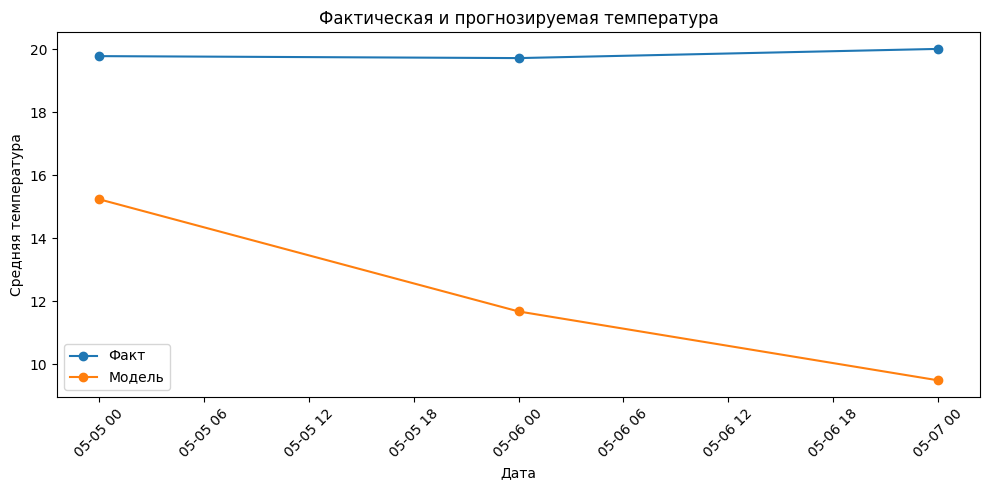

In [28]:
plt.figure(figsize=(10, 5))

plt.plot(
    predictions["date"],
    predictions["actual_t_mean"],
    marker="o",
    label="Факт",
)

plt.plot(
    predictions["date"],
    predictions["model_pred"],
    marker="o",
    label="Модель",
)

plt.title("Фактическая и прогнозируемая температура")
plt.xlabel("Дата")
plt.ylabel("Средняя температура")
plt.xticks(rotation=45)

plt.legend()

plt.tight_layout()

plt.show()

In [26]:
metrics = pd.DataFrame({
    "Модель": ["Baseline", "Linear Regression"],
    "MAE": [baseline_mae, model_mae],
    "R2": [baseline_r2, model_r2],
})

metrics

,Модель,MAE,R2
0,Baseline,3.211806,-656.154141
1,Linear Regression,7.700833,-4153.569375
